# Lesson 9: Tube Design and Orthogonality

Lessons 7-8 designed **one** complex at a time. Real applications - barcodes,
multiplexed probes, orthogonal logic gates - need a whole *library* of
strands that each fold correctly **and don't cross-react with each other**.
This notebook designs multiple complexes in a single `TargetTube`, uses
`off_targets` to actively suppress unwanted complexes, and builds a
**crosstalk matrix** to verify orthogonality with `tube_analysis` (lesson 5).

**By the end of this notebook you will be able to:**

- Put multiple `TargetComplex`es in one `TargetTube`'s `on_targets`, and use
  `off_targets=SetSpec(max_size=...)` to penalize unwanted complexes during
  design.
- Build a **crosstalk matrix**: a heatmap of pairwise complex concentrations
  across a library of strands, using `tube_analysis` from lesson 5.
- Recognize what a *failure* of orthogonality looks like in that matrix, and
  explain it in terms of complementarity.

**Prerequisites:** [`05_basic_tube_analysis.ipynb`](05_basic_tube_analysis.ipynb)
(`Tube`, `tube_analysis`, multi-strand concentrations) and
[`07_intro_design.ipynb`](07_intro_design.ipynb)/[`08_design_constraints.ipynb`](08_design_constraints.ipynb)
(`tube_design`, `TargetTube`).


## Introduction

So far, every `TargetTube` has had a single `TargetComplex` in `on_targets`.
Nothing stops you from listing several:

```python
tube = TargetTube(on_targets={c1: 1e-6, c2: 1e-6, c3: 1e-6}, ...)
```

`tube_design` will then minimize a *weighted sum* of each complex's defect -
designing all of them **together**, in a shared sequence space. But "each
complex individually has low defect" doesn't by itself guarantee the strands
don't interact with *each other*. That's what `off_targets` is for:

```python
tube = TargetTube(on_targets={...}, off_targets=SetSpec(max_size=2), name=...)
```

`off_targets=SetSpec(max_size=2)` tells the optimizer to also consider every
complex of up to 2 strands that *isn't* one of the `on_targets` - each such
complex gets an implicit target concentration of 0, so the optimizer is
penalized if any of them forms appreciably. This is exactly the mechanism
that makes a set of designed strands **orthogonal**: each one folds into its
own target structure, and none of them prefer to bind each other.

### Roadmap

1. Jointly design three hairpins with `off_targets=SetSpec(max_size=2)`.
2. Build a **crosstalk matrix**: mix all three designed strands in one tube
   (lesson 5's `tube_analysis`) and look at every pairwise complex
   concentration as a heatmap.
3. Deliberately break orthogonality - add a "rogue" strand that is the exact
   reverse complement of one library member - and see what that looks like in
   the matrix.


## Setup


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)


def find_conc(conc_dict, *strands):
    '''Look up the equilibrium concentration of the complex containing exactly these strands.'''
    names = sorted(s.name for s in strands)
    for cx, val in conc_dict.items():
        if sorted(s.name for s in cx.strands) == names:
            return val
    return 0.0


COMPLEMENT = {"A": "U", "U": "A", "G": "C", "C": "G"}


def reverse_complement(seq):
    return "".join(COMPLEMENT[b] for b in reversed(seq))


## Theory: from per-complex defect to a crosstalk matrix

**Joint design with off-targets.** With $k$ on-target complexes (here, $k$
single-stranded hairpins) and `off_targets=SetSpec(max_size=2)`, the
optimizer's objective includes the defect of each on-target *and* a term for
every 2-strand complex not in `on_targets` - i.e. every possible heterodimer
and homodimer among the $k$ strands. Driving those terms down means driving
their equilibrium concentrations toward 0, which is exactly "this strand
doesn't bind that one."

**Crosstalk matrix.** Given $k$ designed strands at equal concentration $C$ in
one tube (`Tube(strands={...: C, ...}, complexes=SetSpec(max_size=2))`,
lesson 5), define a $k \times k$ matrix

$$
M_{ij} = \frac{[\text{complex}(i, j)]_{\text{eq}}}{C}
$$

where $\text{complex}(i,i)$ is the homodimer of strand $i$ with itself. A
perfectly orthogonal library has $M \approx 0$ everywhere except the diagonal
of the corresponding *monomer* concentrations being $\approx 1$ (i.e. every
strand stays a monomer, in its own hairpin). Any large off-diagonal entry
means strands $i$ and $j$ prefer to bind each other over folding into their
own target structures.


## Worked example 1: a library of three orthogonal hairpins

Design three independent 14-nt hairpins (target `(((((....)))))`, the same
structure as lessons 7-8) **together**, with `off_targets=SetSpec(max_size=2)`
suppressing all pairwise interactions.


In [2]:
hairpin_target = "(((((....)))))"
n_strands = 3

domains = [Domain("N14", name=f"d{i}") for i in range(n_strands)]
target_strands = [TargetStrand([d], name=f"ts{i}") for i, d in enumerate(domains)]
target_complexes = [TargetComplex([s], hairpin_target, name=f"tc{i}") for i, s in enumerate(target_strands)]

library_tube = TargetTube(
    on_targets={c: 1e-6 for c in target_complexes},
    off_targets=SetSpec(max_size=2),
    name="library_tube",
)

library_results = tube_design(tubes=[library_tube], model=model).run(trials=3)
best_library = min(library_results, key=lambda r: r.ensemble_defect)
print(f"best ensemble defect: {best_library.ensemble_defect:.5f}")

library_seqs = [str(best_library.domains[d]) for d in domains]
library_names = [f"H{i+1}" for i in range(n_strands)]
for name, seq in zip(library_names, library_seqs):
    print(name, seq)


best ensemble defect: 0.00987
H1 GGUCCAUGCGGACC
H2 GAUCCUGACGGAUC
H3 GCGGGAACCCCCGC


## Visualization: crosstalk matrix for the library

Mix all three designed strands at 1 $\mu$M each and run `tube_analysis` with
`SetSpec(max_size=2)` (lesson 5) - then build $M_{ij}$ as defined above.


In [3]:
def crosstalk_matrix(strands, model, conc=1e-6):
    tube = Tube(strands={s: conc for s in strands}, complexes=SetSpec(max_size=2), name="crosstalk")
    result = tube_analysis(tubes=[tube], model=model, compute=["pfunc"])
    cc = result[tube].complex_concentrations

    n = len(strands)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            v = find_conc(cc, strands[i], strands[j]) / conc
            matrix[i, j] = v
            matrix[j, i] = v

    monomer = np.array([find_conc(cc, s) / conc for s in strands])
    return matrix, monomer


library_strands = [Strand(seq, name=name) for seq, name in zip(library_seqs, library_names)]
M_library, monomer_library = crosstalk_matrix(library_strands, model)

print("monomer fractions:", dict(zip(library_names, np.round(monomer_library, 4))))
display(pd.DataFrame(M_library, index=library_names, columns=library_names))


monomer fractions: {'H1': np.float64(0.9998), 'H2': np.float64(1.0), 'H3': np.float64(1.0)}


,H1,H2,H3
H1,7.623057e-05,1.450297e-08,1.981293e-10
H2,1.450297e-08,2.382461e-05,3.721727e-10
H3,1.981293e-10,3.721727e-10,9.436694e-06


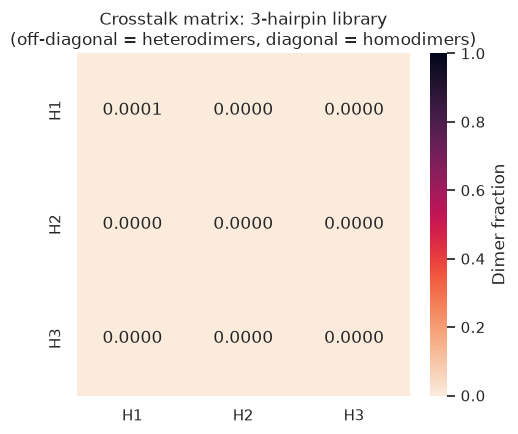

In [4]:
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(
    M_library, annot=True, fmt=".4f", cmap="rocket_r", vmin=0, vmax=1,
    xticklabels=library_names, yticklabels=library_names,
    cbar_kws={"label": "Dimer fraction"}, ax=ax,
)
ax.set_title("Crosstalk matrix: 3-hairpin library\n(off-diagonal = heterodimers, diagonal = homodimers)")
fig.tight_layout()
plt.show()


**Interpretation.** Every entry of $M$ is essentially 0 - none of the three
strands form any appreciable dimer with themselves or each other, and the
monomer fractions are all $\approx 1$. This is what a successful
`off_targets=SetSpec(max_size=2)` design looks like: each strand
independently folds into its own hairpin, and the library is **orthogonal**.


## Worked example 2: a rogue strand

What does a *failure* of orthogonality look like in this matrix? Add a fourth
strand `R` that is the exact **reverse complement** of `H1` - by construction,
`R` and `H1` are perfectly complementary across their full length, so they can
form an 14-bp duplex that competes directly with `H1`'s own hairpin.


In [5]:
rogue_seq = reverse_complement(library_seqs[0])
print(f"H1: {library_seqs[0]}")
print(f"R  (reverse complement of H1): {rogue_seq}")

rogue_strand = Strand(rogue_seq, name="R")
all_strands = library_strands + [rogue_strand]
all_names = library_names + ["R"]

M_rogue, monomer_rogue = crosstalk_matrix(all_strands, model)

print("monomer fractions:", dict(zip(all_names, np.round(monomer_rogue, 4))))
display(pd.DataFrame(M_rogue, index=all_names, columns=all_names))


H1: GGUCCAUGCGGACC
R  (reverse complement of H1): GGUCCGCAUGGACC
monomer fractions: {'H1': np.float64(0.0044), 'H2': np.float64(1.0), 'H3': np.float64(1.0), 'R': np.float64(0.0044)}


,H1,H2,H3,R
H1,1.460027e-09,6.347061e-11,8.670906e-13,9.956243e-01
H2,6.347061e-11,2.382461e-05,3.721727e-10,5.788364e-08
H3,8.670906e-13,3.721727e-10,9.436694e-06,1.895254e-12
R,9.956243e-01,5.788364e-08,1.895254e-12,1.260286e-08


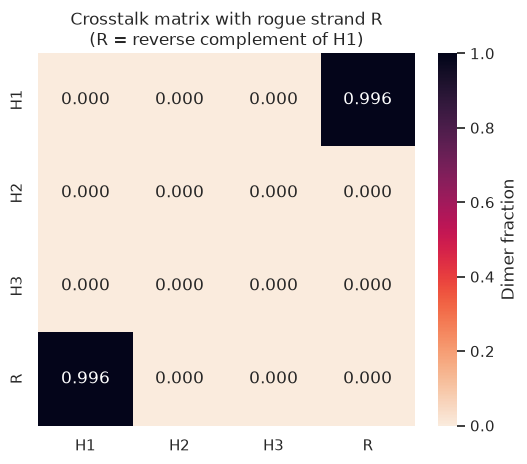

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
sns.heatmap(
    M_rogue, annot=True, fmt=".3f", cmap="rocket_r", vmin=0, vmax=1,
    xticklabels=all_names, yticklabels=all_names,
    cbar_kws={"label": "Dimer fraction"}, ax=ax,
)
ax.set_title("Crosstalk matrix with rogue strand R\n(R = reverse complement of H1)")
fig.tight_layout()
plt.show()


**Interpretation.** The $(H1, R)$ entry jumps to $\approx 0.996$ - almost all
of `H1` and `R` end up bound to each other as a duplex, not folded as their
own hairpins. Correspondingly, `H1`'s and `R`'s monomer fractions both crash
to $\approx 0.004$, while `H2` and `H3` are completely unaffected (their rows
and columns are unchanged from worked example 1). **This is exactly the
failure mode `off_targets=SetSpec(max_size=2)` is designed to prevent** - had
`R` been part of the original joint design, the optimizer would have
penalized any sequence this complementary to another library member.


## Best practices and common pitfalls

- **Orthogonality is a property of the whole library, not of any one
  sequence.** A strand can have excellent on-target defect (lesson 4) in
  isolation and still be a poor library member if it happens to be
  complementary to another member - always check the *crosstalk matrix*,
  not just individual defects.
- **`off_targets=SetSpec(max_size=2)` only considers up to 2-strand
  complexes.** If your application could form 3-strand off-targets (e.g.
  three probes ganging up on each other), you'd need `max_size=3` - at the
  cost of a much larger off-target set (lesson 5's combinatorial growth
  warning applies here too).
- **The crosstalk matrix is symmetric and the diagonal means something
  different than the off-diagonal.** Diagonal entries are *homodimers*
  (strand $i$ with a second copy of itself); off-diagonal entries are
  *heterodimers*. Both should be small for an orthogonal library, but they
  arise from different sequence features (self-complementarity vs.
  cross-complementarity).
- **A single rogue/contaminant strand can be diagnosed the same way.** If a
  real experiment shows unexpected behavior, computing the crosstalk matrix
  for the actual strands present (including any suspected contaminants) is a
  quick way to check for an unintended near-complementary pair.


## Summary

In this notebook you:

1. Designed multiple `TargetComplex`es in one `TargetTube`, using
   `off_targets=SetSpec(max_size=2)` to penalize unwanted
   homodimers/heterodimers during the search.
2. Built a **crosstalk matrix** with `tube_analysis` (lesson 5) and confirmed
   a successfully-designed library has near-zero off-diagonal entries.
3. Saw what orthogonality *failure* looks like - a single reverse-complement
   "rogue" strand dominates the matrix entry for its target, without
   affecting unrelated library members.

**Next:** [`10_multitube_design.ipynb`](10_multitube_design.ipynb) is a case
study that ties the whole series together: multiple `TargetTube`s with
different on/off-targets (e.g. representing different experimental
conditions), followed by a full re-analysis/verification dashboard using
tools from every previous lesson.


## Exercises

1. Increase the library to 4 hairpins (`n_strands = 4`) with
   `off_targets=SetSpec(max_size=2)`. Does the best `ensemble_defect`
   increase compared to the 3-strand library - i.e. does suppressing more
   pairwise off-targets make the joint design harder?
2. Instead of a *full* reverse complement, construct a rogue strand `R2` that
   is the reverse complement of only the first 8 nucleotides of `H1` (with
   the remaining 6 nucleotides random). Recompute the crosstalk matrix - is
   the $(H1, R2)$ entry as large as the full-length rogue's, smaller, or
   negligible?
